# Rip-Tide — a quantitative teardown 🔬
### Gross-vs-net Sharpe · the cost wall & break-even · turnover · the holding-period rescue · horizon & sub-period decay

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Rescue by slowing down?: Busted](https://img.shields.io/badge/Rescue_by_slowing_down%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim with its number.* The steelman: short-horizon contrarian trading is a robust, real anomaly. We confirm the apparatus captures it where it exists (synthetic control), then show that on deep liquid futures there is **no gross premium** and the turnover makes the net **a `MIRAGE`** — the exact mirror of Study 31's trend result.

> ⚠️ **Not investment advice.** The core executes on a synthetic Ornstein-Uhlenbeck reverting panel; the real 18-futures run is in [`../docs/results.md`](../docs/results.md), sources in [`../docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from rip_tide import data, strategy, costs, extension

# Offline synthetic control: an Ornstein-Uhlenbeck mean-reverting panel (the machinery) + a random-walk null.
# The real 18-futures verdict is in ../docs/results.md.
r, truth = data.synthetic_reversion(revert_strength=0.06, seed=32)
r0, _ = data.synthetic_reversion(revert_strength=0.0, seed=32)
print(f"synthetic control: {truth.n_markets} markets x {truth.n_days} days, revert_strength {truth.revert_strength} (null=0)")


synthetic control: 18 markets x 5040 days, revert_strength 0.06 (null=0)


## Beat 0 · Verdict

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — reversion real on futures? | 🔴 `NONE` | Gross Sharpe **0.08**; negative in all 3 sub-periods (**-0.39/-0.89/-0.42**). |
| **Tradability** | 🔴 `MIRAGE` | Turnover **1.38**/day ⇒ break-even **0.24 bp**; net @2 bp Sharpe **-0.56**, DD **-88%**. |
| **Rescue by slowing down?** | ⚪ `Busted` | Net Sharpe across holds 1→21d never > 0 (**-0.56→-0.17→-0.20**). |

> **In one sentence:** a real stock-market anomaly that has no counterpart on the deepest futures — gross-zero, and turnover-killed net — and that no amount of slowing down can save.

*(This notebook executes on the synthetic control; the real numbers are in [`../docs/results.md`](../docs/results.md).)*

## Beat 1 · The claim, precisely

Per market $i$: signal $s_{i,t} = -\mathrm{sign}\!\big(\tfrac13\sum_{L\in\{1,3,5\}}\mathrm{sign}(P_{i,t}/P_{i,t-L}-1)\big)$, lagged. Position $w_{i,t} = s_{i,t}\cdot\min(\sigma^\star_{\text{mkt}}/\hat\sigma_{i,t},\,c)$, then the book is scaled to a portfolio vol target. *Identical to Study 31 except for the leading minus sign.* Claim: the portfolio earns a positive premium from fading short-horizon moves. Null: i.i.d. returns ⇒ no autocorrelation to fade.

In [2]:
for label, rr in [('reverting panel', r), ('null', r0)]:
    g = strategy.summary(strategy.book_returns(rr, cost_bps=0.0))
    print(f"{label:16} gross Sharpe {g['sharpe']:+.2f}  CAGR {g['cagr']*100:+.1f}%  turnover/day {strategy.turnover(rr):.2f}")

reverting panel  gross Sharpe +2.90  CAGR +34.0%  turnover/day 1.67
null             gross Sharpe -0.09  CAGR -1.4%  turnover/day 1.57


> 💡 **In plain words.** The control has a genuine multi-day overshoot, so the book makes money gross (**2.90**); the null has none (**-0.09**). The machine can see reversion when it's there. Now point it at the real market.

## Beat 2 · So what?

Reversion is the canonical *liquidity-provision* premium: Lo–MacKinlay (1990) decompose contrarian profit into own- and cross-autocorrelation and a cross-sectional variance term; Nagel (2012) shows the payoff is the expected return on supplying liquidity, spiking when it evaporates. The pre-registered prediction, then, is that on the *deepest* instruments — where liquidity is never scarce — the premium should be smallest. Beats 4–6 test exactly that.

## Beat 3 · Pre-registered protocol

1. **Real?** `book_returns(cost_bps=0)` on control vs null and on the real tape (gross).
2. **Tradable?** `strategy.turnover`, `costs.breakeven_cost_bps`, `costs.cost_sweep`, vs `costs.long_only_basket`.
3. **Saveable?** `extension.holding_period_sweep` — net Sharpe as a function of holding period.
4. **Robust?** `extension.horizon_sweep` + `extension.subperiod_sharpe`.

**Mirage line:** break-even cost < ~1 bp (the real cost of trading ES).

## Beat 4 · The teardown

### 4a · Gross-zero on the real tape (the NONE call)

In [3]:
print('Real tape (../docs/results.md):')
print('  contrarian gross   Sharpe 0.08  CAGR 0.2%  maxDD -51%  skew -1.03')
print('  contrarian net@2bp Sharpe -0.56  CAGR -6.5%  maxDD -88%')
print('  long-only basket   Sharpe 0.51  CAGR 7.7%  maxDD -55%')
# on the synthetic control the timing genuinely adds (reversion is strong there):
print('\nSynthetic control:')
print(f"  contrarian gross  Sharpe {strategy.summary(strategy.book_returns(r, cost_bps=0.0))['sharpe']:.2f}")
print(f"  long-only basket  Sharpe {strategy.summary(costs.long_only_basket(r))['sharpe']:.2f}")

Real tape (../docs/results.md):
  contrarian gross   Sharpe 0.08  CAGR 0.2%  maxDD -51%  skew -1.03
  contrarian net@2bp Sharpe -0.56  CAGR -6.5%  maxDD -88%
  long-only basket   Sharpe 0.51  CAGR 7.7%  maxDD -55%

Synthetic control:


  contrarian gross  Sharpe 2.90
  long-only basket  Sharpe 0.02


> 💡 **In plain words.** Where overshoot is real (the control) fading it beats owning the basket; on the real, efficient futures tape there's no overshoot left, so the always-long basket wins even *before* costs. The signal is `NONE` on the thing we actually care about.

### 4b · The cost wall and the break-even (the MIRAGE call)

Real cost sweep (net Sharpe, ../docs/results.md):
  0bp 0.075   1bp -0.241   2bp -0.557   5bp -1.497   10bp -3.026
  turnover/day 1.38   break-even 0.24 bp  (ES costs ~1 bp to trade)



synthetic break-even: 7.09 bp


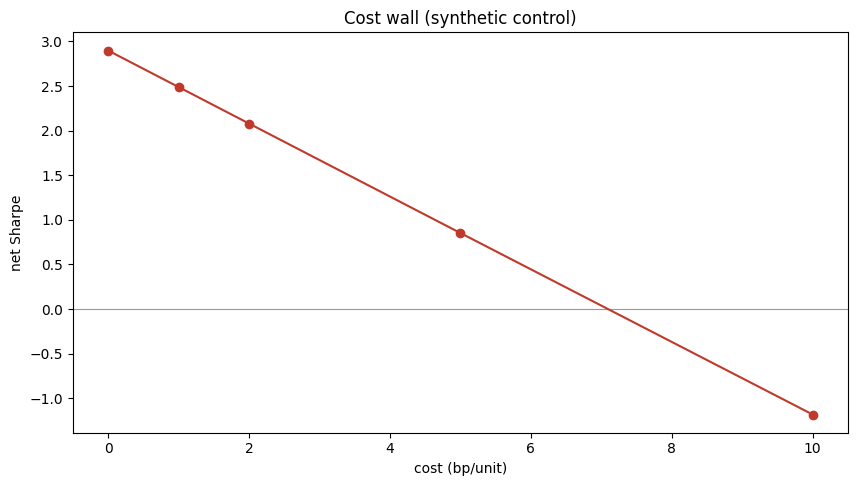

In [4]:
print('Real cost sweep (net Sharpe, ../docs/results.md):')
print('  0bp 0.075   1bp -0.241   2bp -0.557   5bp -1.497   10bp -3.026')
print(f'  turnover/day 1.38   break-even 0.24 bp  (ES costs ~1 bp to trade)')
# drawn on the synthetic, where there is an edge for cost to erode:
cs = costs.cost_sweep(r)
fig, ax = plt.subplots(); ax.axhline(0, color='#999', lw=.8)
ax.plot(cs.index, cs['sharpe'], marker='o', color='#c0392b')
ax.set_xlabel('cost (bp/unit)'); ax.set_ylabel('net Sharpe'); ax.set_title('Cost wall (synthetic control)')
print('\nsynthetic break-even:', round(costs.breakeven_cost_bps(r), 2), 'bp')

## Beat 5 · The verdict

- **`NONE`** (4a, Beat 1): real gross Sharpe 0.08; control 2.90 vs null -0.09.
- **`MIRAGE`** (4b): break-even 0.24 bp < real cost; net @2 bp -0.56, DD -88%.
- **Rescue `BUSTED`** (Beat 7): net Sharpe across holds never > 0.

> **Signal `NONE` · Tradability `MIRAGE` · Rescue? `BUSTED`** — the exact mirror of Trade-Winds.

## Beat 6 · Could you trade it?

- **No.** Break-even 0.24 bp is below the real cost of trading even ES. There is no account structure — retail or institutional — that nets a positive return here.
- **Capacity is irrelevant** when the gross edge is zero; you can't scale nothing.
- **Where the premium actually lives:** illiquid single stocks and crisis windows (Avramov–Chordia–Goyal 2006; Nagel 2012), not deep futures. That's the constructive lesson.

## Beat 7 · Going further

### 7a · Worked complement — the holding-period rescue ([`../docs/extension.md`](../docs/extension.md))
The book dies on turnover, so we slow it down: hold each position $h$ days and re-measure the *net* Sharpe. On the synthetic here, on the real tape in [`../docs/extension.md`](../docs/extension.md).

,gross_sharpe,net_sharpe,turnover_per_day
hold_days,,,
1,2.898,2.079,1.667
2,2.862,2.391,0.963
5,2.394,2.111,0.568
10,1.941,1.804,0.277
21,1.818,1.751,0.135


Real tape net Sharpe by hold (../docs/extension.md): 1d -0.56, 2d -0.17, 5d -0.18, 10d -0.16, 21d -0.20 -- never > 0. BUSTED.


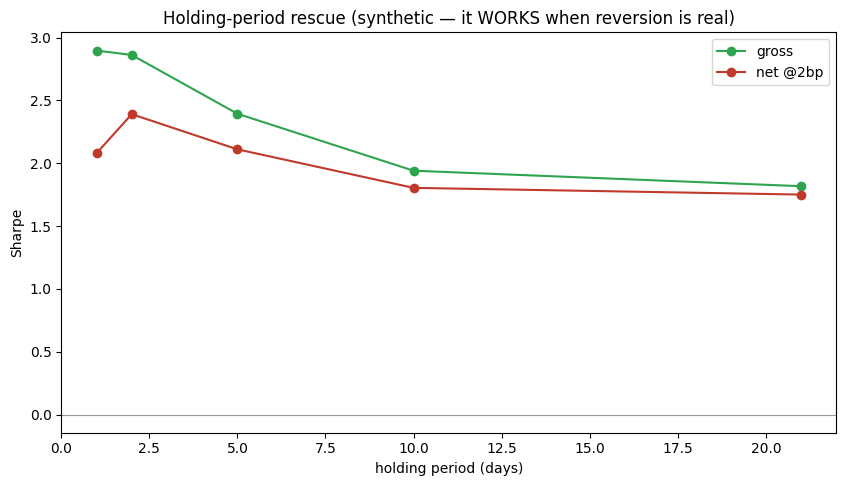

In [5]:
hp = extension.holding_period_sweep(r, holds=[1,2,5,10,21], cost_bps=2.0)
display(hp.round(3))
fig, ax = plt.subplots(); ax.axhline(0, color='#999', lw=.8)
ax.plot(hp.index, hp['gross_sharpe'], marker='o', label='gross', color='#2ea44f')
ax.plot(hp.index, hp['net_sharpe'], marker='o', label='net @2bp', color='#c0392b')
ax.set_xlabel('holding period (days)'); ax.set_ylabel('Sharpe'); ax.legend(); ax.set_title('Holding-period rescue (synthetic — it WORKS when reversion is real)')
print('Real tape net Sharpe by hold (../docs/extension.md): '
      '1d -0.56, 2d -0.17, 5d -0.18, 10d -0.16, 21d -0.20 -- never > 0. BUSTED.')

> 💡 **In plain words.** On the synthetic, slowing down keeps the net Sharpe high (>1.75 even at 21 days) because the overshoot persists for weeks. On the real tape the same knob does nothing useful — the edge and the cost vanish together. That contrast is the cleanest possible evidence that the *market*, not the method, lacks the premium.

### 7b · The horizon sweep & the honest sub-period decay
Not a mis-tuned lookback (negative across every short horizon), and negative in every epoch.

In [6]:
print('Real horizon sweep (net Sharpe @2bp, ../docs/results.md):')
print('  1d -1.01   3d -0.57   5d -0.26   10d -0.41   blend -0.56')
print('\nReal sub-period Sharpe: -0.39 / -0.89 / -0.42 -- negative in all three.')
print('\nSynthetic horizon sweep (where the edge IS there):')
print(extension.horizon_sweep(r).round(3).to_string())

Real horizon sweep (net Sharpe @2bp, ../docs/results.md):
  1d -1.01   3d -0.57   5d -0.26   10d -0.41   blend -0.56

Real sub-period Sharpe: -0.39 / -0.89 / -0.42 -- negative in all three.

Synthetic horizon sweep (where the edge IS there):


               sharpe  cagr
lookback_days              
1               0.057 0.001
3               1.783 0.194
5               2.520 0.288
10              3.356 0.402
1+3+5           2.079 0.232


**The result.** The apparatus captures reversion wherever it exists (synthetic control, every horizon, every holding period) — and finds **none** on 18 deep futures, at any horizon, in any epoch, gross or net. A clean, durable `NONE`/`MIRAGE`, and a `BUSTED` rescue. Full runs in [`../docs/results.md`](../docs/results.md) and [`../docs/extension.md`](../docs/extension.md).

### 7c · Other forks
- **Cross-sectional reversion** — relative winners within an asset class vs each market's own past.
- **Illiquid universe** — single-stock futures / small-caps, where the liquidity premium survives.
- **Crisis-conditional sizing** — trade it only when liquidity evaporates (Nagel 2012).

PRs welcome — try the cross-sectional cut, an illiquid universe, or a stress gate.